In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('.'))

from xso.parscans import run_xso_parscan

from cariaco_ssm_setup import model, model_setup, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets
from parscan_utils import (
    compute_cost_grid, find_best_fit, get_default_from_setup,
)
from parscan_plots import (
    plot_cost_heatmap,
    plot_model_vs_obs_boxplots, summarize_best_fit,
)

In [2]:
REGIME = 'all'
obs_vec, labels, bin_defs, monthly_df, forcing = load_cariaco_targets(regime=REGIME)

print(f"Observation targets (regime='{REGIME}'):")
for lab, val in zip(labels, obs_vec):
    print(f"  {lab:20s}: {val:.5f}")
print(f"Months in filtered dataset: {len(monthly_df)}")
print(f"Regime forcing:")
print(f"  Inflow__FN = {forcing['Inflow__FN']:.4f}  mmol N m-2 d-1")
print(f"  Inflow__de = {forcing['Inflow__de']:.2f}  m")
print(f"  (F_N/d_e   = {forcing['Inflow__FN']/forcing['Inflow__de']:.6f}  mmol N m-3 d-1)")

Observation targets (regime='all'):
  Pico (<2 µm)        : 0.09698
  Nano (2-20 µm)      : 0.08512
  Micro (>20 µm)      : 0.19977
  Zoo >200 µm         : 0.05938
  Zoo >500 µm         : 0.03302
  NO3                 : 1.46705
  PP                  : 0.43247
  Export              : 3.18267
Months in filtered dataset: 255
Regime forcing:
  Inflow__FN = 2.6834  mmol N m-2 d-1
  Inflow__de = 45.58  m
  (F_N/d_e   = 0.058877  mmol N m-3 d-1)


In [3]:
# Which parameters to scan, their ranges, and grid resolution
P1_NAME   = 'Grazing__KsZ'
P1_LABEL  = 'Grazing K_half (mmol N m⁻³)'
P1_VALUES = np.linspace(0.1, 3.0, 30)

P2_NAME   = 'FishGrazing__rate'
P2_LABEL  = 'Fish predation rate (d⁻¹)'
P2_VALUES = np.linspace(0.001, 0.1, 30)

# Scan runtime settings
N_PROCESSES = 20
AVG_WINDOW  = 1000   # days at tail of IVP to average for steady-state cost

print(f"2D scan: {P1_NAME} ({len(P1_VALUES)} pts)  x  {P2_NAME} ({len(P2_VALUES)} pts)")
print(f"Total runs: {len(P1_VALUES) * len(P2_VALUES)}")

2D scan: Grazing__KsZ (30 pts)  x  FishGrazing__rate (30 pts)
Total runs: 900


In [4]:
scan_results = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup',
    param_name=P1_NAME,
    param_values=P1_VALUES,
    param_name2=P2_NAME,
    param_values2=P2_VALUES,
    processes=N_PROCESSES,
    fixed_overrides=forcing,
)

PROGRESS: Completed 30/30 outer points. (Grazing__KsZ = 3.0).

2D Scan complete. Total Time taken: 178.27808 seconds.


In [5]:
cost_grid, model_grid = compute_cost_grid(
    scan_results,
    phyto_esd=phyto_esd,
    zoo_esd=zoo_esd,
    obs_vec=obs_vec,
    bin_definitions=bin_defs,
    avg_window=AVG_WINDOW,
    dim1_name=P1_NAME,
    dim2_name=P2_NAME,
)

best = find_best_fit(cost_grid, model_grid, scan_results, P1_NAME, P2_NAME)

default = {
    'val1': get_default_from_setup(model_setup, P1_NAME),
    'val2': get_default_from_setup(model_setup, P2_NAME),
}

title_info = (f"{P1_NAME}={best['val1']:.4f}, "
              f"{P2_NAME}={best['val2']:.4f}, "
              f"cost={best['cost']:.3f}")

print(f"\n--- Best fit ---")
print(f"  {P1_LABEL}: {best['val1']:.5f}")
print(f"  {P2_LABEL}: {best['val2']:.5f}")
print(f"  Cost (NRMSRE): {best['cost']:.4f}")


--- Best fit ---
  Grazing K_half (mmol N m⁻³): 0.20000
  Fish predation rate (d⁻¹): 0.10000
  Cost (NRMSRE): 0.3366


In [6]:
print(scan_results.Growth__uptake_value)

<xarray.DataArray 'Growth__uptake_value' (FishGrazing__rate: 30,
                                          Grazing__KsZ: 30, phyto: 12,
                                          time: 5000)> Size: 432MB
array([[[[1.38836107e-03, 1.38836107e-03, 1.69036435e-03, ...,
          1.16248618e-03, 1.17091635e-03, 1.18620218e-03],
         [1.54964480e-03, 1.54964480e-03, 1.95292862e-03, ...,
          3.16880833e-08, 3.00455714e-08, 2.86893744e-08],
         [1.65365268e-03, 1.65365268e-03, 2.17665378e-03, ...,
          2.73284420e-02, 2.70927322e-02, 2.67890502e-02],
         ...,
         [7.60978628e-05, 7.60978628e-05, 1.02312601e-04, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [3.88018640e-05, 3.88018640e-05, 5.25681220e-05, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [1.97183467e-05, 1.97183467e-05, 2.69057340e-05, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[1.40888551e-03, 1.40888551e-03, 1.77085

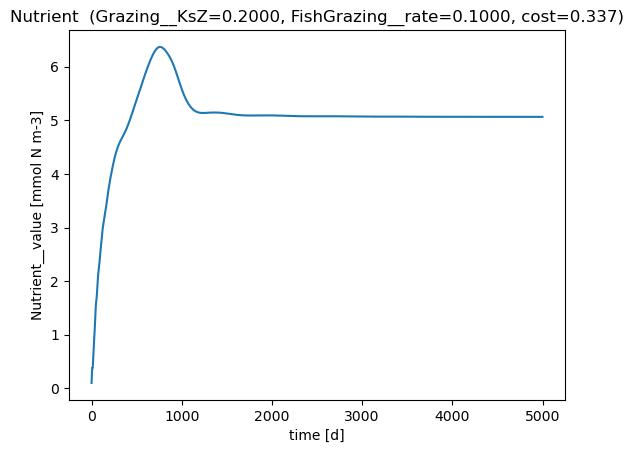

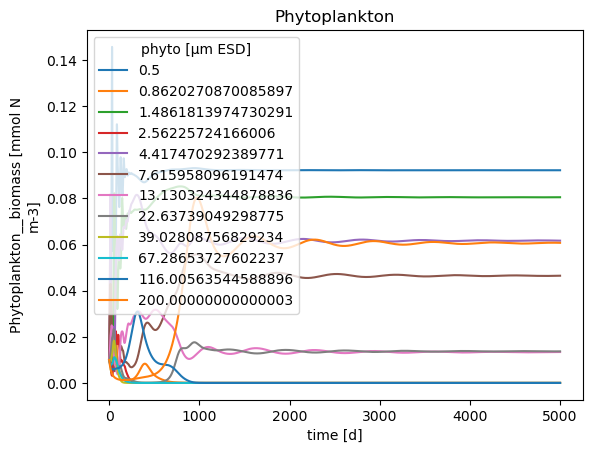

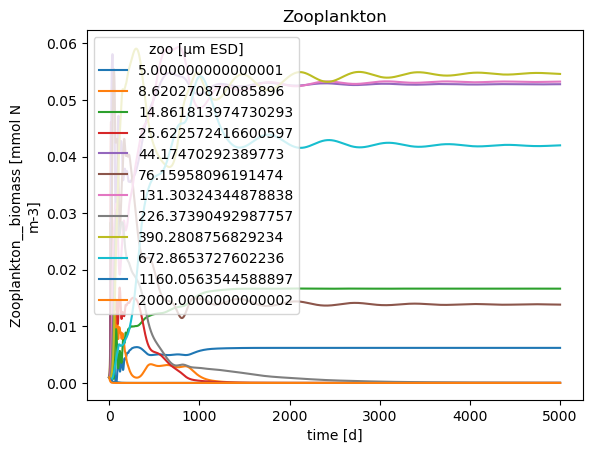

In [7]:
best_run = scan_results.sel({P1_NAME: best['val1'], P2_NAME: best['val2']},
                            method='nearest')

best_run['Nutrient__value'].plot.line(x='time')
plt.title(f'Nutrient  ({title_info})')
plt.show()

best_run['Phytoplankton__biomass'].plot.line(x='time')
plt.title('Phytoplankton')
plt.show()

best_run['Zooplankton__biomass'].plot.line(x='time')
plt.title('Zooplankton')
plt.show()

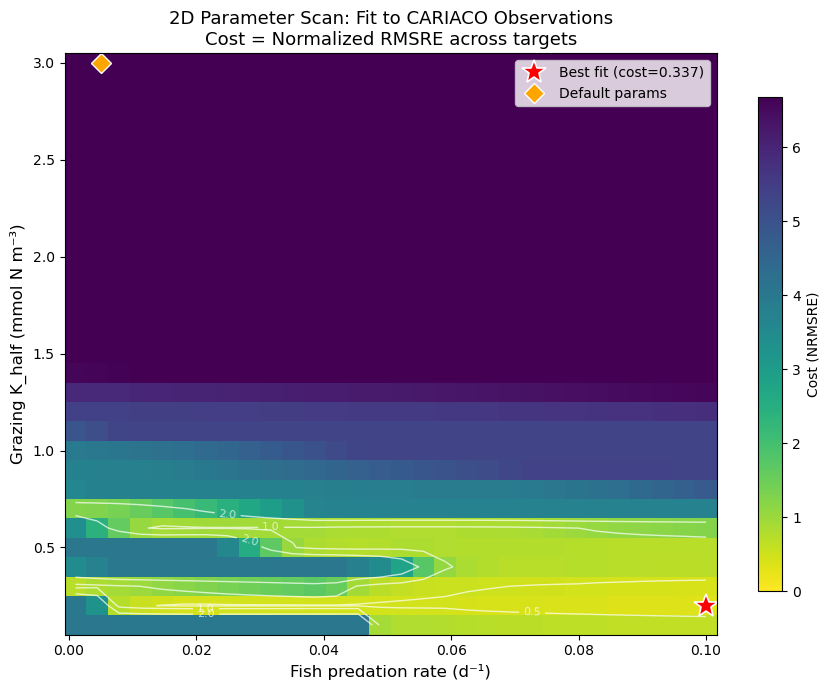

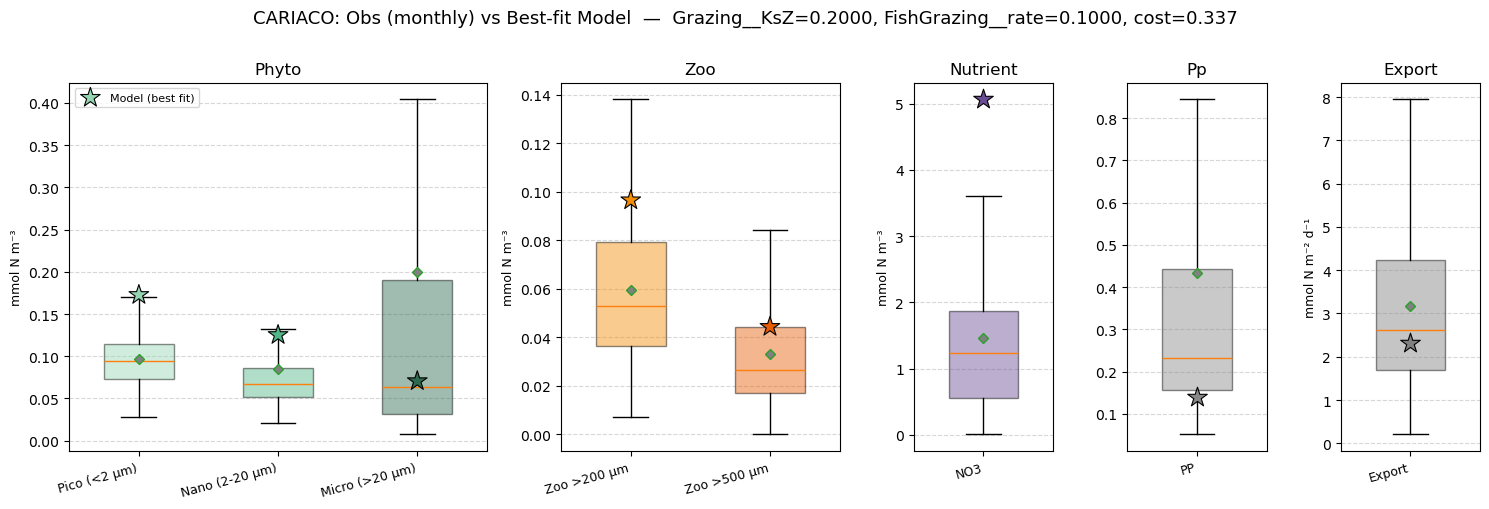

In [8]:
fig1 = plot_cost_heatmap(cost_grid, P1_VALUES, P2_VALUES,
                         P1_LABEL, P2_LABEL, best, default=default)
plt.show()

fig3 = plot_model_vs_obs_boxplots(best['model_vec'], monthly_df, bin_defs,
                                  title_info=title_info)
plt.show()

In [9]:
summary = summarize_best_fit(
    model_vec=best['model_vec'],
    obs_vec=obs_vec,
    labels=labels,
    cost=best['cost'],
)


 BEST-FIT SUMMARY  |  Overall cost (NRMSRE): 0.3366
     Component  Obs_Mean  Model_BestFit   Ratio  Rel_Error_%
  Pico (<2 µm)   0.09698        0.17274 1.78122     78.12153
Nano (2-20 µm)   0.08512        0.12531 1.47224     47.22409
Micro (>20 µm)   0.19977        0.07065 0.35366    -64.63379
   Zoo >200 µm   0.05938        0.09660 1.62695     62.69503
   Zoo >500 µm   0.03302        0.04439 1.34408     34.40766
           NO3   1.46705        5.06571 3.45299    245.29894
            PP   0.43247        0.13947 0.32250    -67.74953
        Export   3.18267        2.31725 0.72809    -27.19147


In [10]:
best_run

<xarray.Dataset> Size: 17MB
Dimensions:                                (time: 5000, phyto: 12, zoo: 12,
                                            full: 24, clock: 2)
Coordinates:
  * time                                   (time) float64 40kB 0.0 ... 4.999e+03
  * phyto                                  (phyto) float64 96B 0.5 ... 200.0
  * zoo                                    (zoo) float64 96B 5.0 8.62 ... 2e+03
  * clock                                  (clock) int64 16B 0 1
    FishGrazing__rate                      float64 8B 0.1
    Grazing__KsZ                           float64 8B 0.2
    Inflow__FN                             float64 8B 2.683
    Inflow__de                             float64 8B 45.58
Dimensions without coordinates: full
Data variables: (12/76)
    Core__solver_type                      <U9 36B 'solve_ivp'
    DetritusRemin__detritus                <U1 4B 'D'
    DetritusRemin__k_remin                 float64 8B 0.1
    DetritusRemin__nutrient                <U1 4B 'N'
    DetritusRemin__remineralization_value  (time) float64 40kB 0.001143 ... 0...
    DetritusSink__detritus                 <U1 4B 'D'
    ...                                     ...
    ZooMortality__rate                     float64 8B 0.1
    Zooplankton__biomass                   (zoo, time) float64 480kB 0.001 .....
    Zooplankton__biomass_init              (zoo) float64 96B 0.001 ... 0.001
    Zooplankton__biomass_label             <U1 4B 'Z'
    Zooplankton__zoo_esd_index             (zoo) float64 96B 5.0 8.62 ... 2e+03
    Zooplankton__zoo_esd_label             <U7 28B 'zoo_esd'